# Phase 2b: 分布・相関構造の監査

Phase 2b: Distribution & Correlation Audit for β-conditioned DDPM
=================================================================

┌──────────────────────────────────────────────────────────────┐
│ 目的: Phase 2a の DDPM が ⟨|P|⟩ の平均だけでなく、         │
│ 分布全体と相関構造まで MC と一致するかを検証する。          │
│                                                              │
│ 監査項目:                                                    │
│   1. |P| 分布: ヒストグラム + KS検定 + W₁距離               │
│   2. Susceptibility χ と Binder cumulant U₄                  │
│   3. 空間相関関数 C(r) = ⟨P(0)P*(r)⟩ と相関長 ξ           │
│   4. Vortex/winding map: arg P(x,y) から位相欠陥を抽出      │
│                                                              │
│ 設計原則 (TopoCycleGAN failure analysis より):               │
│   - 学習解像度 = 評価解像度 (32×32, リサンプリングなし)     │
│   - 物理量で直接評価 (代理指標に依存しない)                 │
│   - 視覚的監査を必須化                                      │
└──────────────────────────────────────────────────────────────┘

## Kaggle での実行手順
1. **Add Data**: Phase 1 dataset (`phase1-dataset`) を追加
2. **Add Data**: Phase 2a checkpoint (`phase2a-checkpoint`) を追加
3. **Accelerator**: GPU T4 を選択（生成を高速化）
4. 上から順にセルを実行

## 0. データ探索 & チェックポイント検出

In [5]:
import os, glob

# ── Phase 1 データ (.npz) を探す ──
DATA_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    npz = [f for f in files if f.endswith('.npz')]
    if npz:
        DATA_DIR = root
        print(f".npz 発見: {DATA_DIR}")
        print(f"  ファイル数: {len(npz)}")
        print(f"  サンプル: {npz[:5]}")
        break

if DATA_DIR is None:
    raise FileNotFoundError("Phase 1 の .npz データが見つかりません。Add Data で追加してください。")

# ── Phase 2a チェックポイント (.pt) を探す ──
CKPT_PATH = None
for root, dirs, files in os.walk('/kaggle/input'):
    pts = [f for f in files if f.endswith('.pt')]
    if pts:
        # ckpt_final.pt を優先、なければ最大 epoch のものを使う
        if 'ckpt_final.pt' in pts:
            CKPT_PATH = os.path.join(root, 'ckpt_final.pt')
        else:
            pts_sorted = sorted(pts)
            CKPT_PATH = os.path.join(root, pts_sorted[-1])
        print(f"\nCheckpoint 発見: {CKPT_PATH}")
        break

if CKPT_PATH is None:
    raise FileNotFoundError("Phase 2a のチェックポイント (.pt) が見つかりません。Add Data で追加してください。")

.npz 発見: /kaggle/input/datasets/mokafe/phase1-dataset
  ファイル数: 10
  サンプル: ['beta_2.0000.npz', 'beta_1.5000.npz', 'beta_0.5000.npz', 'beta_1.9000.npz', 'beta_4.0000.npz']

Checkpoint 発見: /kaggle/input/models/mokafe/phase2a-ddpm-checkpoint/pytorch/default/1/ckpt_final.pt


## 1. セットアップ & モデル定義（Phase 2a と同一）

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import os
import json
import time
from scipy import stats as sp_stats

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB


In [7]:
# ── Phase 2a モデル定義（チェックポイントロードに必要）──
# ここは Phase 2a と完全に同一のコード。変更不可。

def circ_conv(in_ch, out_ch, kernel_size=3, stride=1, bias=True):
    return nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride,
                     padding=kernel_size // 2, padding_mode='circular', bias=bias)

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)

class ConditionEmbedding(nn.Module):
    def __init__(self, d_model=256):
        super().__init__()
        self.time_sin = SinusoidalEmbedding(d_model)
        self.time_mlp = nn.Sequential(nn.Linear(d_model, d_model), nn.SiLU(), nn.Linear(d_model, d_model))
        self.beta_mlp = nn.Sequential(nn.Linear(1, d_model), nn.SiLU(), nn.Linear(d_model, d_model))
        self.combine = nn.Sequential(nn.SiLU(), nn.Linear(d_model, d_model))
    def forward(self, t, beta_normed):
        t_emb = self.time_mlp(self.time_sin(t))
        b_emb = self.beta_mlp(beta_normed[:, None])
        return self.combine(t_emb + b_emb)

class AdaGN(nn.Module):
    def __init__(self, n_channels, d_cond, n_groups=8):
        super().__init__()
        self.gn = nn.GroupNorm(n_groups, n_channels, affine=False)
        self.proj = nn.Linear(d_cond, 2 * n_channels)
    def forward(self, x, cond):
        h = self.gn(x)
        scale, shift = self.proj(cond)[:, :, None, None].chunk(2, dim=1)
        return h * (1 + scale) + shift

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, d_cond=256, n_groups=8):
        super().__init__()
        self.conv1 = circ_conv(in_ch, out_ch)
        self.adagn = AdaGN(out_ch, d_cond, n_groups=min(n_groups, out_ch))
        self.conv2 = circ_conv(out_ch, out_ch)
        self.act = nn.SiLU()
        self.skip_proj = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, cond):
        h = self.act(self.conv1(x))
        h = self.act(self.adagn(h, cond))
        h = self.conv2(h)
        return h + self.skip_proj(x)

class SelfAttention(nn.Module):
    def __init__(self, channels, n_heads=4):
        super().__init__()
        self.n_heads = n_heads
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, 3 * channels, 1)
        self.out = nn.Conv2d(channels, channels, 1)
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, self.n_heads, C // self.n_heads, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        attn = torch.einsum("bhdn,bhdm->bhnm", q, k) / math.sqrt(C // self.n_heads)
        attn = attn.softmax(dim=-1)
        out = torch.einsum("bhnm,bhdm->bhdn", attn, v)
        out = out.reshape(B, C, H, W)
        return x + self.out(out)

class UNet(nn.Module):
    def __init__(self, in_ch=2, ch_mults=(64, 128, 256), d_cond=256):
        super().__init__()
        self.cond_emb = ConditionEmbedding(d_cond)
        c0, c1, c2 = ch_mults
        self.in_conv = circ_conv(in_ch, c0)
        self.down1a = ResBlock(c0, c0, d_cond); self.down1b = ResBlock(c0, c0, d_cond)
        self.pool1 = nn.Conv2d(c0, c0, 3, stride=2, padding=1, padding_mode='circular')
        self.down2a = ResBlock(c0, c1, d_cond); self.down2b = ResBlock(c1, c1, d_cond)
        self.pool2 = nn.Conv2d(c1, c1, 3, stride=2, padding=1, padding_mode='circular')
        self.down3a = ResBlock(c1, c2, d_cond); self.down3b = ResBlock(c2, c2, d_cond)
        self.pool3 = nn.Conv2d(c2, c2, 3, stride=2, padding=1, padding_mode='circular')
        self.bot1 = ResBlock(c2, c2, d_cond); self.bot_attn = SelfAttention(c2); self.bot2 = ResBlock(c2, c2, d_cond)
        self.up3 = nn.ConvTranspose2d(c2, c2, 2, stride=2)
        self.dec3a = ResBlock(c2 + c2, c2, d_cond); self.dec3b = ResBlock(c2, c2, d_cond)
        self.up2 = nn.ConvTranspose2d(c2, c1, 2, stride=2)
        self.dec2a = ResBlock(c1 + c1, c1, d_cond); self.dec2b = ResBlock(c1, c1, d_cond)
        self.up1 = nn.ConvTranspose2d(c1, c0, 2, stride=2)
        self.dec1a = ResBlock(c0 + c0, c0, d_cond); self.dec1b = ResBlock(c0, c0, d_cond)
        self.out_norm = nn.GroupNorm(8, c0)
        self.out_conv = circ_conv(c0, in_ch)
        nn.init.zeros_(self.out_conv.weight); nn.init.zeros_(self.out_conv.bias)
    def forward(self, x, t, beta_normed):
        cond = self.cond_emb(t, beta_normed)
        h = self.in_conv(x)
        s1 = self.down1b(self.down1a(h, cond), cond); h = self.pool1(s1)
        s2 = self.down2b(self.down2a(h, cond), cond); h = self.pool2(s2)
        s3 = self.down3b(self.down3a(h, cond), cond); h = self.pool3(s3)
        h = self.bot1(h, cond); h = self.bot_attn(h); h = self.bot2(h, cond)
        h = self.up3(h); h = self.dec3b(self.dec3a(torch.cat([h, s3], dim=1), cond), cond)
        h = self.up2(h); h = self.dec2b(self.dec2a(torch.cat([h, s2], dim=1), cond), cond)
        h = self.up1(h); h = self.dec1b(self.dec1a(torch.cat([h, s1], dim=1), cond), cond)
        return self.out_conv(F.silu(self.out_norm(h)))

class CosineSchedule:
    def __init__(self, T=1000, s=0.008):
        self.T = T
        steps = torch.arange(T + 1, dtype=torch.float64)
        f = torch.cos((steps / T + s) / (1 + s) * math.pi / 2) ** 2
        alpha_bar = f / f[0]
        betas = (1 - alpha_bar[1:] / alpha_bar[:-1]).clamp(max=0.999)
        self.betas = betas.float()
        self.alphas = (1 - self.betas).float()
        self.alpha_bar = torch.cumprod(self.alphas, dim=0).float()
        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1 - self.alpha_bar)
    def to(self, device):
        for attr in ['betas','alphas','alpha_bar','sqrt_alpha_bar','sqrt_one_minus_alpha_bar']:
            setattr(self, attr, getattr(self, attr).to(device))
        return self
    def p_sample(self, model, x_t, t, beta_normed):
        B = x_t.shape[0]
        t_tensor = torch.full((B,), t, device=x_t.device, dtype=torch.long)
        with torch.no_grad():
            eps_pred = model(x_t, t_tensor, beta_normed)
        alpha = self.alphas[t]; beta = self.betas[t]
        coef1 = 1 / torch.sqrt(alpha)
        coef2 = beta / self.sqrt_one_minus_alpha_bar[t]
        mean = coef1 * (x_t - coef2 * eps_pred)
        if t > 0:
            return mean + torch.sqrt(beta) * torch.randn_like(x_t)
        return mean
    @torch.no_grad()
    def sample(self, model, shape, beta_normed, show_progress=True):
        x = torch.randn(shape, device=beta_normed.device)
        steps = range(self.T - 1, -1, -1)
        if show_progress:
            try:
                from tqdm import tqdm; steps = tqdm(steps, desc="Sampling")
            except ImportError: pass
        for t in steps:
            x = self.p_sample(model, x, t, beta_normed)
        return x

print("モデル定義完了")

モデル定義完了


## 2. チェックポイントのロード & MC データの読み込み

In [8]:
# ── 2.1 EMA モデルのロード ──
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

ema_model = UNet(in_ch=2).to(device)
ema_model.load_state_dict(ckpt['ema_model'])
ema_model.eval()
n_params = sum(p.numel() for p in ema_model.parameters())
print(f"EMA model loaded: {n_params:,} params ({n_params/1e6:.1f}M)")
print(f"  Trained for {ckpt.get('epoch', '?')} epochs, {ckpt.get('global_step', '?')} steps")

# β 正規化パラメータを取得
ds_info = ckpt.get('dataset_info', {})
BETA_MIN = ds_info.get('beta_min', 0.5)
BETA_MAX = ds_info.get('beta_max', 10.0)
print(f"  β range: [{BETA_MIN}, {BETA_MAX}]")

def beta_to_normed(beta_phys):
    return (beta_phys - BETA_MIN) / (BETA_MAX - BETA_MIN + 1e-8)

schedule = CosineSchedule(T=1000).to(device)
print("Schedule ready")

EMA model loaded: 12,091,522 params (12.1M)
  Trained for 200 epochs, 125000 steps
  β range: [0.5, 10.0]
Schedule ready


In [9]:
# ── 2.2 MC データ（Phase 1 .npz）の読み込み ──
# β ごとに Re, Im を辞書に格納

mc_data = {}  # {beta_phys: {'re': (N,32,32), 'im': (N,32,32)}}

for fpath in sorted(glob.glob(os.path.join(DATA_DIR, '*.npz'))):
    fname = os.path.basename(fpath)
    beta = float(fname.split('beta_')[1].split('.npz')[0])
    data = np.load(fpath)
    mc_data[beta] = {
        're': data['poly_re'].astype(np.float32),
        'im': data['poly_im'].astype(np.float32),
    }
    n = mc_data[beta]['re'].shape[0]
    print(f"β={beta:5.2f}: {n} configs loaded")

print(f"\nMC data: {len(mc_data)} β values")

β= 0.50: 500 configs loaded
β= 1.00: 500 configs loaded
β= 1.50: 500 configs loaded
β= 1.70: 500 configs loaded
β= 1.90: 500 configs loaded
β=10.00: 500 configs loaded
β= 2.00: 500 configs loaded
β= 2.50: 500 configs loaded
β= 4.00: 500 configs loaded
β= 6.00: 500 configs loaded

MC data: 10 β values


## 3. DDPM サンプル大量生成

各 β で 1000 枚生成。Phase 2a の 100 枚から 10 倍に増やし、
分布比較の統計精度を確保する。

In [10]:
N_GEN = 1000           # β あたりの生成枚数
GEN_BATCH = 100        # GPU メモリに合わせて分割

# 評価対象 β: 訓練 β + held-out β
eval_betas = sorted(mc_data.keys())  # MC データがある β 全て
held_out = [1.75, 1.85, 3.0, 8.0]
all_betas = sorted(set(list(eval_betas) + held_out))

print(f"生成対象: {len(all_betas)} β values, 各 {N_GEN} 枚")
print(f"  β = {all_betas}")

gen_data = {}  # {beta: {'re': (N,32,32), 'im': (N,32,32)}}

t_start = time.time()
for beta_phys in all_betas:
    bn = beta_to_normed(beta_phys)
    all_samples = []
    
    n_batches = math.ceil(N_GEN / GEN_BATCH)
    for i in range(n_batches):
        bs = min(GEN_BATCH, N_GEN - i * GEN_BATCH)
        beta_tensor = torch.full((bs,), bn, device=device)
        samples = schedule.sample(ema_model, (bs, 2, 32, 32), beta_tensor, show_progress=False)
        all_samples.append(samples.cpu().numpy())
    
    all_samples = np.concatenate(all_samples, axis=0)  # (N, 2, 32, 32)
    gen_data[beta_phys] = {
        're': all_samples[:, 0],  # (N, 32, 32)
        'im': all_samples[:, 1],
    }
    
    elapsed = time.time() - t_start
    print(f"β={beta_phys:5.2f}: {all_samples.shape[0]} 枚生成完了 ({elapsed:.0f}s)")

print(f"\n全生成完了: {time.time()-t_start:.0f}s")

生成対象: 14 β values, 各 1000 枚
  β = [0.5, 1.0, 1.5, 1.7, 1.75, 1.85, 1.9, 2.0, 2.5, 3.0, 4.0, 6.0, 8.0, 10.0]
β= 0.50: 1000 枚生成完了 (829s)
β= 1.00: 1000 枚生成完了 (1665s)
β= 1.50: 1000 枚生成完了 (2500s)
β= 1.70: 1000 枚生成完了 (3336s)
β= 1.75: 1000 枚生成完了 (4171s)
β= 1.85: 1000 枚生成完了 (5006s)
β= 1.90: 1000 枚生成完了 (5842s)
β= 2.00: 1000 枚生成完了 (6678s)
β= 2.50: 1000 枚生成完了 (7513s)
β= 3.00: 1000 枚生成完了 (8348s)
β= 4.00: 1000 枚生成完了 (9184s)
β= 6.00: 1000 枚生成完了 (10019s)
β= 8.00: 1000 枚生成完了 (10854s)
β=10.00: 1000 枚生成完了 (11689s)

全生成完了: 11689s


## 4. 解析ユーティリティ関数

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4.1  |P| 計算（空間平均 Polyakov loop の絶対値）
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def compute_poly_abs(re, im):
    """各配位の空間平均 |P| を計算。
    re, im: (N, Ns, Ns)
    returns: (N,)
    """
    avg_re = re.mean(axis=(1, 2))  # (N,)
    avg_im = im.mean(axis=(1, 2))
    return np.sqrt(avg_re**2 + avg_im**2)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4.2  Susceptibility χ と Binder cumulant U₄
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def susceptibility(poly_abs, Ns=32):
    """Polyakov loop susceptibility: χ = Ns² × (⟨|P|²⟩ − ⟨|P|⟩²)"""
    return Ns**2 * (np.mean(poly_abs**2) - np.mean(poly_abs)**2)

def binder_cumulant(poly_abs):
    """Binder cumulant: U₄ = 1 − ⟨|P|⁴⟩ / (3 ⟨|P|²⟩²)
    
    U₄ → 2/3 (ordered phase), U₄ → 0 (disordered phase).
    β_c 近傍での U₄ の振る舞いは有限サイズスケーリングの基本ツール。
    """
    m2 = np.mean(poly_abs**2)
    m4 = np.mean(poly_abs**4)
    if m2 == 0:
        return 0.0
    return 1.0 - m4 / (3.0 * m2**2)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4.3  空間相関関数 C(r) = ⟨P(0)P*(r)⟩
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def polyakov_correlation(re, im, max_r=None):
    """PBC を考慮した空間相関関数 C(r) の計算。
    
    P(x,y) = Re(x,y) + i Im(x,y)
    C(r) = ⟨P(x₀) P*(x₀+r)⟩  (空間平均・配位平均)
    
    PBC 上の距離: d = min(|dx|, Ns-|dx|) etc.
    FFT で高速計算: C(r) = IFFT[|FFT[P]|²] / Ns²
    
    re, im: (N, Ns, Ns)
    returns: rs (距離配列), Cr (相関値), Cr_err (標準誤差)
    """
    N, Ns, _ = re.shape
    if max_r is None:
        max_r = Ns // 2
    
    # P = Re + i*Im  (complex field)
    P = re + 1j * im  # (N, Ns, Ns)
    
    # FFT-based correlation: C(dx,dy) = IFFT[|FFT[P]|²] / Ns²
    P_fft = np.fft.fft2(P, axes=(1, 2))
    power = np.abs(P_fft)**2
    corr_2d = np.fft.ifft2(power, axes=(1, 2)).real / (Ns * Ns)  # (N, Ns, Ns)
    
    # Radial binning with PBC distances
    dx = np.arange(Ns)
    dx = np.minimum(dx, Ns - dx)  # PBC folding
    DX, DY = np.meshgrid(dx, dx, indexing='ij')
    R = np.sqrt(DX**2 + DY**2)
    
    # Bin into integer distances
    rs = []
    Cr_mean = []
    Cr_err = []
    
    for r_int in range(max_r + 1):
        mask = (R >= r_int - 0.5) & (R < r_int + 0.5)
        if not mask.any():
            continue
        # Average over spatial bins, then over configs
        vals_per_config = corr_2d[:, mask].mean(axis=1)  # (N,)
        rs.append(r_int)
        Cr_mean.append(vals_per_config.mean())
        Cr_err.append(vals_per_config.std() / np.sqrt(N))
    
    return np.array(rs), np.array(Cr_mean), np.array(Cr_err)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4.4  相関長 ξ の抽出
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def fit_correlation_length(rs, Cr, r_min=1, r_max=10):
    """C(r) ∝ exp(-r/ξ) のフィットから ξ を抽出。
    閉じ込め相でのみ有意。脱閉じ込め相では ξ → ∞。
    """
    from scipy.optimize import curve_fit
    mask = (rs >= r_min) & (rs <= r_max) & (Cr > 0)
    if mask.sum() < 3:
        return np.nan, np.nan
    
    r_fit = rs[mask]
    C_fit = Cr[mask]
    
    def exp_decay(r, A, xi):
        return A * np.exp(-r / xi)
    
    try:
        popt, pcov = curve_fit(exp_decay, r_fit, C_fit, p0=[C_fit[0], 2.0], maxfev=5000)
        return popt[1], np.sqrt(pcov[1, 1])  # xi, xi_err
    except:
        return np.nan, np.nan


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4.5  Vortex/winding map from arg P
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def compute_vortex_map(re, im):
    """arg P(x,y) の位相場から vortex（位相欠陥）を検出。
    
    各プラケット（2×2 の最小ループ）の周りの位相巻き付き数を計算。
    PBC を考慮して端を折り返す。
    
    re, im: (Ns, Ns)  単一配位
    returns: vortex_map (Ns, Ns)  各サイトの巻き付き数 ∈ {-1, 0, +1}
    """
    Ns = re.shape[0]
    theta = np.arctan2(im, re)  # (Ns, Ns), ∈ [-π, π]
    
    # PBC-aware index
    def pbc(i):
        return i % Ns
    
    vortex = np.zeros((Ns, Ns), dtype=np.float64)
    for x in range(Ns):
        for y in range(Ns):
            # Plaquette corners: (x,y) → (x+1,y) → (x+1,y+1) → (x,y+1) → (x,y)
            t0 = theta[x, y]
            t1 = theta[pbc(x+1), y]
            t2 = theta[pbc(x+1), pbc(y+1)]
            t3 = theta[x, pbc(y+1)]
            
            # Winding = sum of angle differences (wrapped to [-π, π])
            def wrap(dtheta):
                return (dtheta + np.pi) % (2 * np.pi) - np.pi
            
            winding = wrap(t1 - t0) + wrap(t2 - t1) + wrap(t3 - t2) + wrap(t0 - t3)
            vortex[x, y] = winding / (2 * np.pi)  # Should be ≈ integer
    
    return np.round(vortex).astype(int)


def vortex_density(re_batch, im_batch):
    """バッチ全体の vortex 密度（|winding| の空間平均）を計算。"""
    densities = []
    for i in range(len(re_batch)):
        v = compute_vortex_map(re_batch[i], im_batch[i])
        densities.append(np.abs(v).mean())
    return np.array(densities)

print("解析関数定義完了")

解析関数定義完了


## 5. 監査 (1): |P| 分布 — KS検定 + W₁距離

Phase 2a では ⟨|P|⟩ の平均のみ検証した。
ここでは分布の形状全体を比較する。

In [16]:
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance

# ── 5.1 数値比較: KS, W₁, χ, U₄ ──
print(f"{'β':>5} {'区分':>8} | {'KS stat':>8} {'KS p':>8} | {'W₁':>8} | "
      f"{'χ_MC':>8} {'χ_gen':>8} | {'U₄_MC':>8} {'U₄_gen':>8}")
print('─' * 95)

dist_results = {}

for beta in sorted(all_betas):
    g = gen_data[beta]
    poly_gen = compute_poly_abs(g['re'], g['im'])
    
    tag = 'HELD-OUT' if beta in held_out else 'TRAIN'
    
    result = {
        'poly_gen': poly_gen,
        'mean_gen': poly_gen.mean(),
        'std_gen': poly_gen.std(),
        'chi_gen': susceptibility(poly_gen),
        'U4_gen': binder_cumulant(poly_gen),
        'tag': tag,
    }
    
    if beta in mc_data:
        m = mc_data[beta]
        poly_mc = compute_poly_abs(m['re'], m['im'])
        
        ks_stat, ks_p = ks_2samp(poly_mc, poly_gen)
        w1 = wasserstein_distance(poly_mc, poly_gen)
        
        result.update({
            'poly_mc': poly_mc,
            'mean_mc': poly_mc.mean(),
            'chi_mc': susceptibility(poly_mc),
            'U4_mc': binder_cumulant(poly_mc),
            'ks_stat': ks_stat, 'ks_p': ks_p, 'w1': w1,
        })
        
        print(f"{beta:5.2f} {tag:>8} | {ks_stat:8.4f} {ks_p:8.4f} | {w1:8.5f} | "
              f"{result['chi_mc']:8.3f} {result['chi_gen']:8.3f} | "
              f"{result['U4_mc']:8.4f} {result['U4_gen']:8.4f}")
    else:
        print(f"{beta:5.2f} {tag:>8} | {'—':>8} {'—':>8} | {'—':>8} | "
              f"{'—':>8} {result['chi_gen']:8.3f} | "
              f"{'—':>8} {result['U4_gen']:8.4f}")
    
    dist_results[beta] = result

    β       区分 |  KS stat     KS p |       W₁ |     χ_MC    χ_gen |    U₄_MC   U₄_gen
───────────────────────────────────────────────────────────────────────────────────────────────
 0.50    TRAIN |   0.0280   0.9543 |  0.00078 |    0.244    0.226 |   0.3097   0.3096
 1.00    TRAIN |   0.0460   0.4765 |  0.00104 |    0.294    0.270 |   0.3475   0.3437
 1.50    TRAIN |   0.0370   0.7470 |  0.00163 |    1.167    1.095 |   0.2893   0.3266
 1.70    TRAIN |   0.0260   0.9766 |  0.00215 |    3.421    3.477 |   0.3785   0.3607
 1.75 HELD-OUT |        —        — |        — |        —    4.744 |        —   0.3444
 1.85 HELD-OUT |        —        — |        — |        —    9.651 |        —   0.4575
 1.90    TRAIN |   0.0470   0.4488 |  0.00667 |    9.796   11.196 |   0.5236   0.5125
 2.00    TRAIN |   0.0450   0.5050 |  0.00764 |    9.120   10.997 |   0.6029   0.5932
 2.50    TRAIN |   0.0770   0.0377 |  0.00604 |    2.535    2.757 |   0.6571   0.6571
 3.00 HELD-OUT |        —        — |        

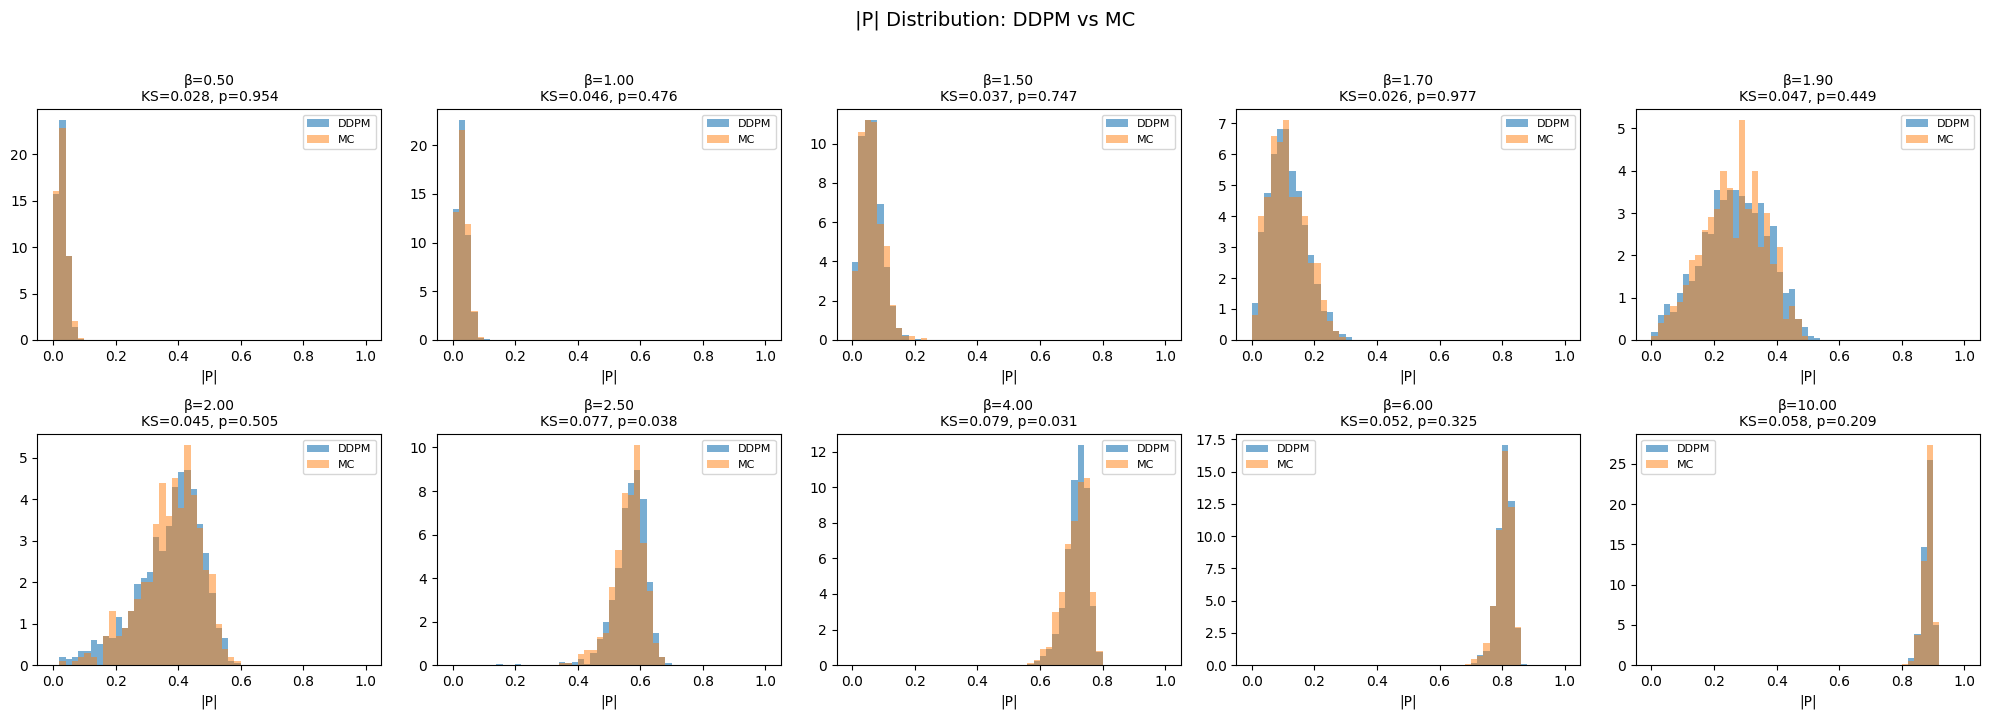

In [17]:
# ── 5.2 ヒストグラム可視化 ──
# 相転移近傍を含む代表的な β を選んで並べる

plot_betas = [0.5, 1.0, 1.5, 1.7, 1.9, 2.0, 2.5, 4.0, 6.0, 10.0]
plot_betas = [b for b in plot_betas if b in dist_results]

n_cols = 5
n_rows = math.ceil(len(plot_betas) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
axes = axes.flatten()

for i, beta in enumerate(plot_betas):
    ax = axes[i]
    r = dist_results[beta]
    
    bins = np.linspace(0, 1, 51)
    ax.hist(r['poly_gen'], bins=bins, density=True, alpha=0.6, color='C0', label='DDPM')
    
    if 'poly_mc' in r:
        ax.hist(r['poly_mc'], bins=bins, density=True, alpha=0.5, color='C1', label='MC')
        ax.set_title(f"β={beta:.2f}\nKS={r['ks_stat']:.3f}, p={r['ks_p']:.3f}", fontsize=10)
    else:
        ax.set_title(f"β={beta:.2f} [held-out]", fontsize=10)
    
    ax.set_xlabel('|P|')
    ax.legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('|P| Distribution: DDPM vs MC', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/phase2b_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

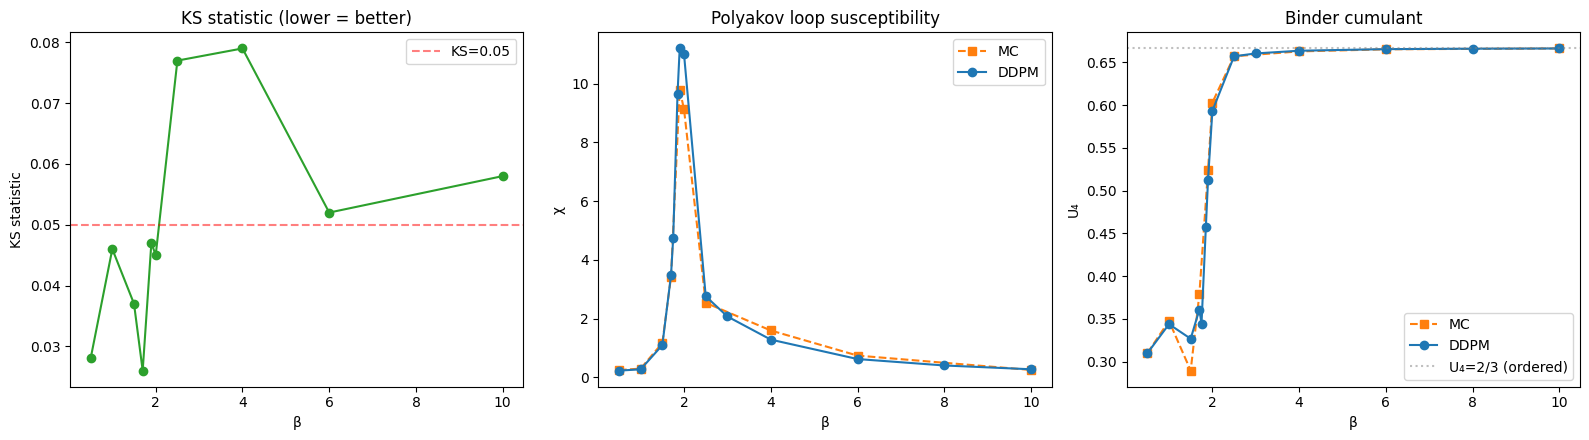

In [18]:
# ── 5.3 χ と U₄ の β 依存性プロット ──

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# MC がある β のみ
mc_betas = sorted([b for b in dist_results if 'chi_mc' in dist_results[b]])
all_sorted = sorted(dist_results.keys())

# (a) KS statistic
ax = axes[0]
ks_vals = [dist_results[b].get('ks_stat', np.nan) for b in mc_betas]
ax.plot(mc_betas, ks_vals, 'o-', color='C2')
ax.axhline(0.05, ls='--', color='red', alpha=0.5, label='KS=0.05')
ax.set_xlabel('β'); ax.set_ylabel('KS statistic')
ax.set_title('KS statistic (lower = better)'); ax.legend()

# (b) Susceptibility
ax = axes[1]
chi_mc = [dist_results[b]['chi_mc'] for b in mc_betas]
chi_gen = [dist_results[b]['chi_gen'] for b in mc_betas]
chi_gen_all = [dist_results[b]['chi_gen'] for b in all_sorted]
ax.plot(mc_betas, chi_mc, 's--', color='C1', label='MC')
ax.plot(all_sorted, chi_gen_all, 'o-', color='C0', label='DDPM')
ax.set_xlabel('β'); ax.set_ylabel('χ')
ax.set_title('Polyakov loop susceptibility'); ax.legend()

# (c) Binder cumulant
ax = axes[2]
U4_mc = [dist_results[b]['U4_mc'] for b in mc_betas]
U4_gen = [dist_results[b]['U4_gen'] for b in mc_betas]
U4_gen_all = [dist_results[b]['U4_gen'] for b in all_sorted]
ax.plot(mc_betas, U4_mc, 's--', color='C1', label='MC')
ax.plot(all_sorted, U4_gen_all, 'o-', color='C0', label='DDPM')
ax.axhline(2/3, ls=':', color='gray', alpha=0.5, label='U₄=2/3 (ordered)')
ax.set_xlabel('β'); ax.set_ylabel('U₄')
ax.set_title('Binder cumulant'); ax.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/phase2b_chi_U4.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 監査 (2): 空間相関関数 C(r) = ⟨P(0)P*(r)⟩

⟨|P|⟩ は空間平均した後の量であり、空間構造の情報が失われている。
C(r) は「距離 r 離れたサイト間の相関」を直接見る、より厳しい検証。

In [19]:
# ── 6.1 C(r) の計算 ──

corr_results = {}

for beta in sorted(all_betas):
    g = gen_data[beta]
    rs_gen, Cr_gen, Ce_gen = polyakov_correlation(g['re'], g['im'])
    
    entry = {'rs_gen': rs_gen, 'Cr_gen': Cr_gen, 'Ce_gen': Ce_gen}
    
    if beta in mc_data:
        m = mc_data[beta]
        rs_mc, Cr_mc, Ce_mc = polyakov_correlation(m['re'], m['im'])
        entry.update({'rs_mc': rs_mc, 'Cr_mc': Cr_mc, 'Ce_mc': Ce_mc})
    
    corr_results[beta] = entry

print("C(r) 計算完了")

C(r) 計算完了


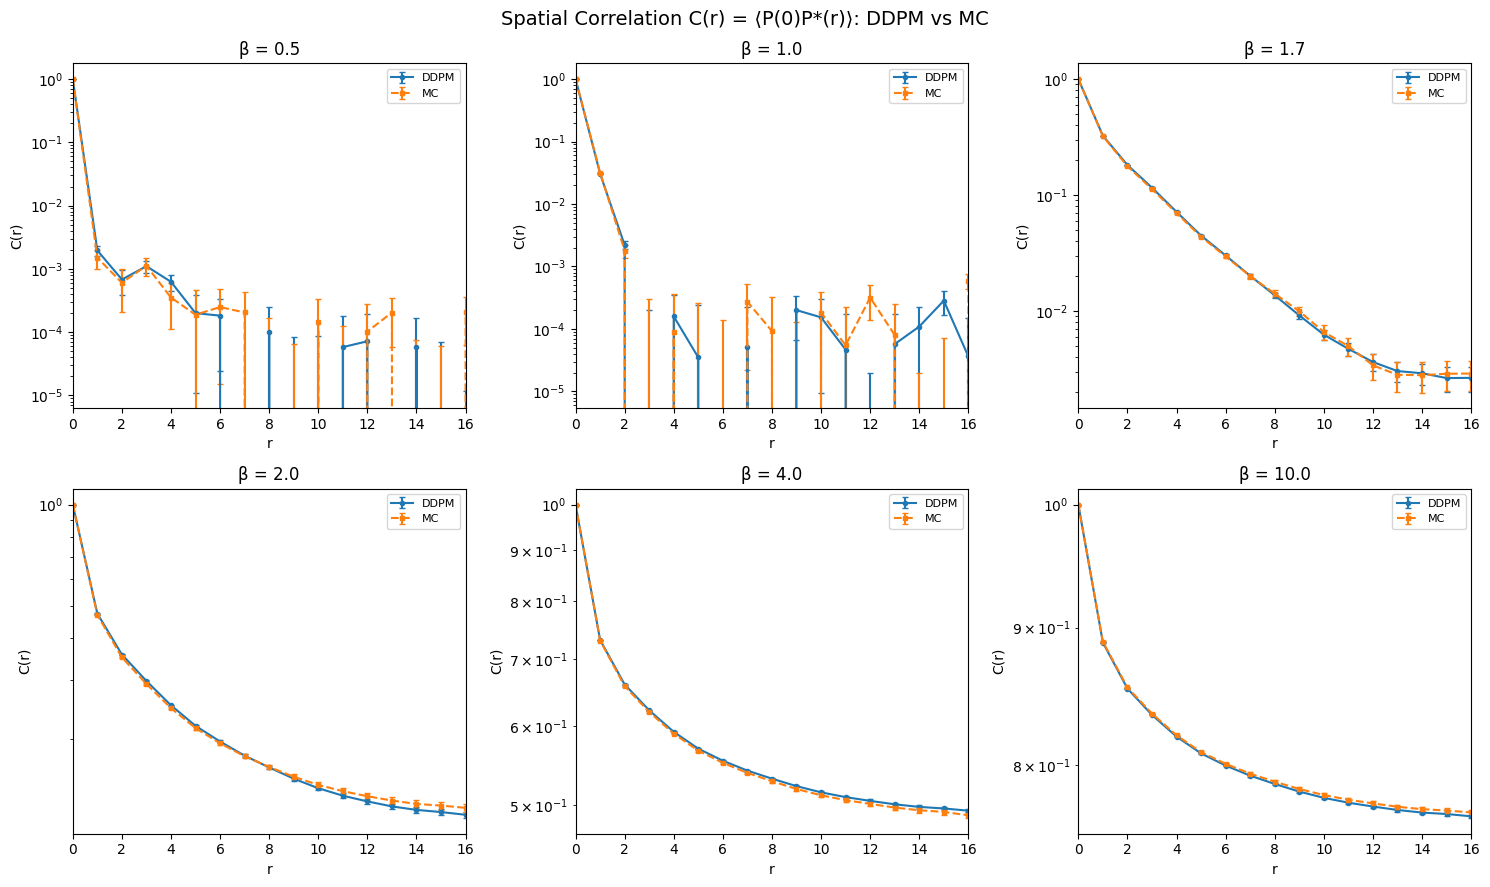

In [20]:
# ── 6.2 C(r) プロット ──

plot_betas_corr = [0.5, 1.0, 1.7, 2.0, 4.0, 10.0]
plot_betas_corr = [b for b in plot_betas_corr if b in corr_results]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, beta in enumerate(plot_betas_corr):
    ax = axes[i]
    cr = corr_results[beta]
    
    ax.errorbar(cr['rs_gen'], cr['Cr_gen'], yerr=cr['Ce_gen'],
                fmt='o-', ms=3, capsize=2, color='C0', label='DDPM')
    
    if 'rs_mc' in cr:
        ax.errorbar(cr['rs_mc'], cr['Cr_mc'], yerr=cr['Ce_mc'],
                    fmt='s--', ms=3, capsize=2, color='C1', label='MC')
    
    ax.set_xlabel('r'); ax.set_ylabel('C(r)')
    ax.set_title(f'β = {beta:.1f}')
    ax.legend(fontsize=8)
    ax.set_yscale('log')
    ax.set_xlim(0, 16)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Spatial Correlation C(r) = ⟨P(0)P*(r)⟩: DDPM vs MC', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/phase2b_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ── 6.3 相関長 ξ の β 依存性 ──

print(f"{'β':>5} | {'ξ_MC':>10} {'ξ_gen':>10} | {'Δξ':>8}")
print('─' * 45)

xi_results = {}

for beta in sorted(all_betas):
    cr = corr_results[beta]
    xi_gen, xi_gen_err = fit_correlation_length(cr['rs_gen'], cr['Cr_gen'])
    
    entry = {'xi_gen': xi_gen, 'xi_gen_err': xi_gen_err}
    
    if 'rs_mc' in cr:
        xi_mc, xi_mc_err = fit_correlation_length(cr['rs_mc'], cr['Cr_mc'])
        entry.update({'xi_mc': xi_mc, 'xi_mc_err': xi_mc_err})
        delta = abs(xi_gen - xi_mc) if not (np.isnan(xi_gen) or np.isnan(xi_mc)) else np.nan
        print(f"{beta:5.2f} | {xi_mc:7.3f}±{xi_mc_err:.3f} {xi_gen:7.3f}±{xi_gen_err:.3f} | {delta:8.3f}")
    else:
        print(f"{beta:5.2f} | {'—':>10} {xi_gen:7.3f}±{xi_gen_err:.3f} | {'—':>8}")
    
    xi_results[beta] = entry

    β |       ξ_MC      ξ_gen |       Δξ
─────────────────────────────────────────────
 0.50 |   2.761±0.796   2.292±0.614 |    0.469
 1.00 |   0.347±0.012   0.380±0.009 |    0.033
 1.50 |   1.066±0.022   1.056±0.017 |    0.010
 1.70 |   1.956±0.064   1.979±0.057 |    0.022
 1.75 |          —   2.300±0.088 |        —
 1.85 |          —   3.607±0.198 |        —
 1.90 |   4.408±0.283   4.430±0.265 |    0.022
 2.00 |   6.835±0.649   6.715±0.574 |    0.120
 2.50 |  14.242±1.664  14.527±1.697 |    0.285
 3.00 |          —  18.526±2.111 |        —
 4.00 |  26.027±3.012  26.402±3.067 |    0.375
 6.00 |  40.915±4.581  41.563±4.747 |    0.649
 8.00 |          —  55.157±6.275 |        —
10.00 |  73.699±8.742  72.714±8.465 |    0.986


## 7. 監査 (3): Vortex / Winding Map

arg P(x,y) の位相場から、各プラケットの巻き付き数を計算する。
これは Phase 2c (PH) へのブリッジであり、位相的構造の最も直接的な可視化。

BKT 転移では vortex-antivortex 対の束縛解離が起きるため、
vortex 密度の β 依存性は相転移の直接的な指標となる。

In [22]:
# ── 7.1 Vortex 密度の β 依存性 ──
# 計算コストが高いので、最初の 200 枚のみ使う

N_VORTEX = min(200, N_GEN)

print(f"Vortex density 計算 (各 β {N_VORTEX} 枚)...")
vortex_results = {}

for beta in sorted(all_betas):
    g = gen_data[beta]
    vd_gen = vortex_density(g['re'][:N_VORTEX], g['im'][:N_VORTEX])
    
    entry = {'vd_gen_mean': vd_gen.mean(), 'vd_gen_std': vd_gen.std()}
    
    if beta in mc_data:
        m = mc_data[beta]
        n_mc = min(N_VORTEX, len(m['re']))
        vd_mc = vortex_density(m['re'][:n_mc], m['im'][:n_mc])
        entry.update({'vd_mc_mean': vd_mc.mean(), 'vd_mc_std': vd_mc.std()})
    
    vortex_results[beta] = entry
    print(f"  β={beta:5.2f}: gen={entry['vd_gen_mean']:.4f}" +
          (f", mc={entry.get('vd_mc_mean', 'N/A')}" if 'vd_mc_mean' in entry else ''))

print("完了")

Vortex density 計算 (各 β 200 枚)...
  β= 0.50: gen=0.3302, mc=0.333232421875
  β= 1.00: gen=0.3085, mc=0.308447265625
  β= 1.50: gen=0.1787, mc=0.1748828125
  β= 1.70: gen=0.1047, mc=0.099580078125
  β= 1.75: gen=0.0941
  β= 1.85: gen=0.0584
  β= 1.90: gen=0.0471, mc=0.04720703125
  β= 2.00: gen=0.0301, mc=0.029677734375
  β= 2.50: gen=0.0059, mc=0.006396484375
  β= 3.00: gen=0.0016
  β= 4.00: gen=0.0001, mc=0.000126953125
  β= 6.00: gen=0.0000, mc=0.0
  β= 8.00: gen=0.0000
  β=10.00: gen=0.0000, mc=0.0
完了


/tmp/ipykernel_55/3302568861.py:46: UserWarning: Glyph 36578 (\N{CJK UNIFIED IDEOGRAPH-8EE2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/3302568861.py:46: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/3302568861.py:46: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/3302568861.py:46: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/3302568861.py:46: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/3302568861.py:47: UserWarning: Glyph 36578 (\N{CJK UNIFIED IDEOGRAPH-8EE2}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/phase2b_vortex.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_55/3302568861.py:47: UserWarning: Glyp

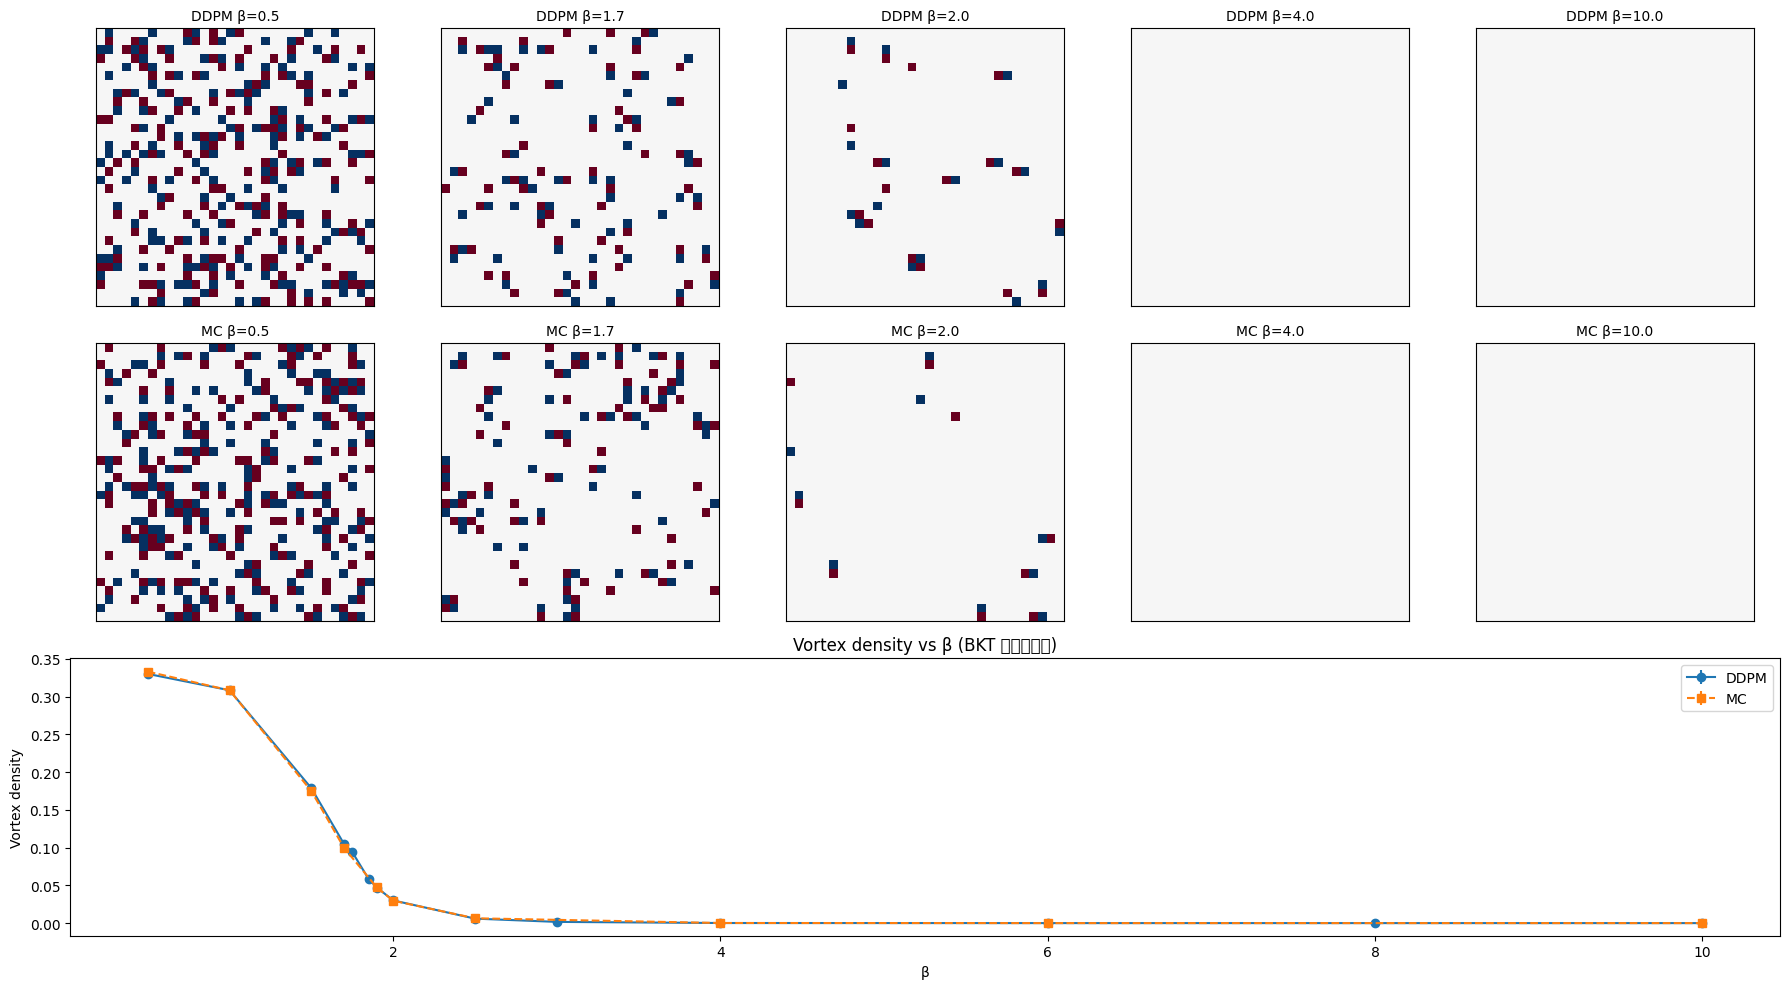

In [23]:
# ── 7.2 Vortex map 可視化 + 密度の β 依存性 ──

fig = plt.figure(figsize=(18, 10))

# (A) 代表的な β での vortex map
vis_betas = [0.5, 1.7, 2.0, 4.0, 10.0]
vis_betas = [b for b in vis_betas if b in gen_data]

for col, beta in enumerate(vis_betas):
    g = gen_data[beta]
    
    # DDPM sample
    ax = fig.add_subplot(3, len(vis_betas), col + 1)
    v_gen = compute_vortex_map(g['re'][0], g['im'][0])
    im = ax.imshow(v_gen, cmap='RdBu', vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(f'DDPM β={beta}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    
    # MC sample (if available)
    ax2 = fig.add_subplot(3, len(vis_betas), len(vis_betas) + col + 1)
    if beta in mc_data:
        m = mc_data[beta]
        v_mc = compute_vortex_map(m['re'][0], m['im'][0])
        ax2.imshow(v_mc, cmap='RdBu', vmin=-1, vmax=1, interpolation='nearest')
        ax2.set_title(f'MC β={beta}', fontsize=10)
    else:
        ax2.text(0.5, 0.5, 'No MC', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_xticks([]); ax2.set_yticks([])

# (B) Vortex density vs β
ax_vd = fig.add_subplot(3, 1, 3)
betas_sorted = sorted(vortex_results.keys())
vd_gen_vals = [vortex_results[b]['vd_gen_mean'] for b in betas_sorted]
vd_gen_errs = [vortex_results[b]['vd_gen_std'] / np.sqrt(N_VORTEX) for b in betas_sorted]
ax_vd.errorbar(betas_sorted, vd_gen_vals, yerr=vd_gen_errs, fmt='o-', color='C0', label='DDPM')

mc_vd_betas = [b for b in betas_sorted if 'vd_mc_mean' in vortex_results[b]]
vd_mc_vals = [vortex_results[b]['vd_mc_mean'] for b in mc_vd_betas]
vd_mc_errs = [vortex_results[b]['vd_mc_std'] / np.sqrt(N_VORTEX) for b in mc_vd_betas]
ax_vd.errorbar(mc_vd_betas, vd_mc_vals, yerr=vd_mc_errs, fmt='s--', color='C1', label='MC')

ax_vd.set_xlabel('β'); ax_vd.set_ylabel('Vortex density')
ax_vd.set_title('Vortex density vs β (BKT 転移の指標)')
ax_vd.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/phase2b_vortex.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 総合サマリー

In [26]:
# ── 8.1 サマリーテーブル ──

print("="*80)
print("Phase 2b 総合サマリー: 分布・相関構造の監査結果")
print("="*80)

print("\n[1] |P| 分布 (KS検定 + W₁距離)")
print(f"{'β':>5} {'KS stat':>8} {'KS p':>8} {'W₁':>8} {'判定':>6}")
print('─' * 45)
for beta in sorted(mc_betas):
    r = dist_results[beta]
    if 'ks_stat' in r:
        verdict = '✓' if r['ks_p'] > 0.01 else '△' if r['ks_p'] > 0.001 else '✗'
        print(f"{beta:5.2f} {r['ks_stat']:8.4f} {r['ks_p']:8.4f} {r['w1']:8.5f} {verdict:>6}")

print("\n[2] Susceptibility χ と Binder cumulant U₄")
print(f"{'β':>5} {'χ_MC':>8} {'χ_DDPM':>8} {'|Δχ/χ|':>8} | {'U₄_MC':>8} {'U₄_DDPM':>8} {'|ΔU₄|':>8}")
print('─' * 70)
for beta in sorted(mc_betas):
    r = dist_results[beta]
    if 'chi_mc' in r:
        dchi = abs(r['chi_mc'] - r['chi_gen']) / (abs(r['chi_mc']) + 1e-10)
        du4 = abs(r['U4_mc'] - r['U4_gen'])
        print(f"{beta:5.2f} {r['chi_mc']:8.3f} {r['chi_gen']:8.3f} {dchi:8.3f} | "
              f"{r['U4_mc']:8.4f} {r['U4_gen']:8.4f} {du4:8.4f}")

print("\n[3] 相関長 ξ")
print(f"{'β':>5} {'ξ_MC':>10} {'ξ_DDPM':>10} {'|Δξ|':>8}")
print('─' * 40)
for beta in sorted(xi_results.keys()):
    xr = xi_results[beta]
    xi_g = xr['xi_gen']
    if 'xi_mc' in xr:
        xi_m = xr['xi_mc']
        delta = abs(xi_g - xi_m) if not (np.isnan(xi_g) or np.isnan(xi_m)) else np.nan
        print(f"{beta:5.2f} {xi_m:10.3f} {xi_g:10.3f} {delta:8.3f}")
    else:
        print(f"{beta:5.2f} {'—':>10} {xi_g:10.3f} {'—':>8}")

print("\n[4] Vortex 密度")
print(f"{'β':>5} {'ρ_MC':>10} {'ρ_DDPM':>10} {'|Δρ/ρ|':>10}")
print('─' * 40)
for beta in sorted(vortex_results.keys()):
    vr = vortex_results[beta]
    if 'vd_mc_mean' in vr:
        dr = abs(vr['vd_mc_mean'] - vr['vd_gen_mean']) / (vr['vd_mc_mean'] + 1e-10)
        print(f"{beta:5.2f} {vr['vd_mc_mean']:10.4f} {vr['vd_gen_mean']:10.4f} {dr:10.4f}")
    else:
        print(f"{beta:5.2f} {'—':>10} {vr['vd_gen_mean']:10.4f} {'—':>10}")

Phase 2b 総合サマリー: 分布・相関構造の監査結果

[1] |P| 分布 (KS検定 + W₁距離)
    β  KS stat     KS p       W₁     判定
─────────────────────────────────────────────
 0.50   0.0280   0.9543  0.00078      ✓
 1.00   0.0460   0.4765  0.00104      ✓
 1.50   0.0370   0.7470  0.00163      ✓
 1.70   0.0260   0.9766  0.00215      ✓
 1.90   0.0470   0.4488  0.00667      ✓
 2.00   0.0450   0.5050  0.00764      ✓
 2.50   0.0770   0.0377  0.00604      ✓
 4.00   0.0790   0.0306  0.00410      ✓
 6.00   0.0520   0.3247  0.00231      ✓
10.00   0.0580   0.2095  0.00121      ✓

[2] Susceptibility χ と Binder cumulant U₄
    β     χ_MC   χ_DDPM   |Δχ/χ| |    U₄_MC  U₄_DDPM    |ΔU₄|
──────────────────────────────────────────────────────────────────────
 0.50    0.244    0.226    0.075 |   0.3097   0.3096   0.0002
 1.00    0.294    0.270    0.083 |   0.3475   0.3437   0.0038
 1.50    1.167    1.095    0.062 |   0.2893   0.3266   0.0373
 1.70    3.421    3.477    0.016 |   0.3785   0.3607   0.0178
 1.90    9.796   11.196    0.143 |

In [27]:
# ── 8.2 結果を JSON で保存 ──

summary = {
    'config': {
        'N_GEN': N_GEN,
        'N_VORTEX': N_VORTEX,
        'checkpoint': CKPT_PATH,
    },
    'distribution': {},
    'correlation_length': {},
    'vortex_density': {},
}

for beta in sorted(all_betas):
    r = dist_results[beta]
    entry = {
        'mean_gen': float(r['mean_gen']),
        'std_gen': float(r['std_gen']),
        'chi_gen': float(r['chi_gen']),
        'U4_gen': float(r['U4_gen']),
        'tag': r['tag'],
    }
    if 'ks_stat' in r:
        entry.update({
            'mean_mc': float(r['mean_mc']),
            'chi_mc': float(r['chi_mc']),
            'U4_mc': float(r['U4_mc']),
            'ks_stat': float(r['ks_stat']),
            'ks_p': float(r['ks_p']),
            'w1': float(r['w1']),
        })
    summary['distribution'][str(beta)] = entry

for beta in sorted(xi_results.keys()):
    xr = xi_results[beta]
    xe = {'xi_gen': float(xr['xi_gen']) if not np.isnan(xr['xi_gen']) else None}
    if 'xi_mc' in xr:
        xe['xi_mc'] = float(xr['xi_mc']) if not np.isnan(xr['xi_mc']) else None
    summary['correlation_length'][str(beta)] = xe

for beta in sorted(vortex_results.keys()):
    vr = vortex_results[beta]
    ve = {'vd_gen': float(vr['vd_gen_mean'])}
    if 'vd_mc_mean' in vr:
        ve['vd_mc'] = float(vr['vd_mc_mean'])
    summary['vortex_density'][str(beta)] = ve

out_path = '/kaggle/working/phase2b_results.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\n結果保存: {out_path}")

print("\n" + "="*80)
print("Phase 2b 完了")
print("="*80)
print("\n出力ファイル:")
print("  /kaggle/working/phase2b_histograms.png   — |P| 分布ヒストグラム")
print("  /kaggle/working/phase2b_chi_U4.png       — χ, U₄ の β 依存性")
print("  /kaggle/working/phase2b_correlation.png   — C(r) 空間相関")
print("  /kaggle/working/phase2b_vortex.png        — Vortex map + 密度")
print("  /kaggle/working/phase2b_results.json      — 全数値結果")


結果保存: /kaggle/working/phase2b_results.json

Phase 2b 完了

出力ファイル:
  /kaggle/working/phase2b_histograms.png   — |P| 分布ヒストグラム
  /kaggle/working/phase2b_chi_U4.png       — χ, U₄ の β 依存性
  /kaggle/working/phase2b_correlation.png   — C(r) 空間相関
  /kaggle/working/phase2b_vortex.png        — Vortex map + 密度
  /kaggle/working/phase2b_results.json      — 全数値結果
